# FIG3: Dataset-size effects on inverse-dynamics accuracy and training cost

This notebook regenerates manuscript Figure 3 from the `FIG3.zip` data archive in the same folder. Every plotted value is read from the archive, and the notebook asserts that no plotted value falls outside its axes before saving `FIG3.svg`, `FIG3.pdf` and `FIG3.png`.


Legend of panel a spans epochs 1944-2760 and 1.89-46.2 Nm, no data underneath.
Axis ranges: a 0.02-50 Nm, d upper 0.005-2 Nm, d lower 20-10800 s; all plotted values inside.
Saved FIG3.svg


Saved FIG3.pdf
Saved FIG3.png


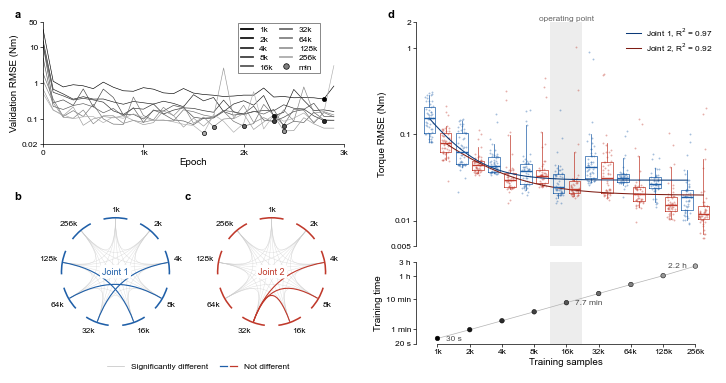

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Wedge
from matplotlib.path import Path as MplPath
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
from matplotlib.legend_handler import HandlerTuple
from scipy.optimize import curve_fit

# -----------------------------------------------------------------------------
# Load data. FIG3.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG3.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG3")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG3.zip or FIG3 in the current folder. "
        "Place the data archive in the same folder as FIG3.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    history = pd.read_csv(archive.open("fig3_test_rmse_history.csv"))
    train_history = pd.read_csv(archive.open("fig3_train_loss_history.csv"))
    training_times = pd.read_csv(archive.open("fig3_training_times.csv"))
    rmse_values = pd.read_csv(archive.open("fig3_rmse_values.csv"))
    best_checkpoints = pd.read_csv(archive.open("fig3_best_checkpoints.csv"))
    pairwise_statistics = pd.read_csv(archive.open("fig3_pairwise_statistics.csv"))
    metadata = json.load(archive.open("fig3_metadata.json"))

DATASET_SIZES = [int(v) for v in metadata["dataset_sizes"]]
ALPHA = 0.05


# -----------------------------------------------------------------------------
# Figure layout. Left: validation RMSE across training (a) over the two chord
# diagrams of pairwise comparisons (d, e). Right: held-out torque RMSE (b) over
# training time (c) on one shared axis of training-set size. Every axis range is
# the tightest pair of labelled ticks that encloses all plotted values, and this is
# asserted before the figure is saved. All inputs come from FIG3.zip.
# -----------------------------------------------------------------------------
J1, J2 = "#1F5FA8", "#C0392B"; J1D, J2D = "#0B3A78", "#7F1D14"
GRAYS = np.linspace(0.0, 0.68, len(DATASET_SIZES))
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 6, "axes.labelsize": 7, "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5, "xtick.major.size": 2, "ytick.major.size": 2,
    "xtick.major.pad": 1.6, "ytick.major.pad": 1.6, "axes.labelpad": 2.0,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none", "savefig.bbox": "standard", "figure.dpi": 100,
})
def gray(size): return str(GRAYS[DATASET_SIZES.index(int(size))])
def fmt(v): v = int(v); return f"{v // 1000}k" if v >= 1000 else str(v)
def open_axes(ax, xb=None, yb=None):
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.tick_params(direction="out")
    if xb: ax.spines["bottom"].set_bounds(*xb)
    if yb: ax.spines["left"].set_bounds(*yb)
def tight_log_limits(values, ticks):
    """Tightest pair of labelled ticks enclosing every value (never clips)."""
    lo = max(t for t in ticks if t <= np.min(values)); hi = min(t for t in ticks if t >= np.max(values)); return lo, hi
def log_axis(ax, which, lo, hi, ticks, labels=None):
    ticks = [t for t in ticks if lo <= t <= hi]
    axis = ax.yaxis if which == "y" else ax.xaxis
    (ax.set_ylim if which == "y" else ax.set_xlim)(lo, hi)
    axis.set_major_locator(FixedLocator(ticks)); axis.set_minor_locator(NullLocator())
    axis.set_major_formatter(FuncFormatter(lambda v, _: labels.get(v, f"{v:g}") if labels else f"{v:g}"))
def power_law(x, a, b, c): return a * np.power(x, -b) + c
def fit_medians(joint):
    x = np.asarray(DATASET_SIZES, float)
    y = np.array([np.median(rmse_values.loc[(rmse_values.dataset_size == s) & (rmse_values.joint == joint), "torque_rmse_nm"]) for s in DATASET_SIZES])
    c0 = max(y.min() * 0.8, 0); a0 = max((y.max() - c0) * np.sqrt(x.min()), 1e-12)
    coeffs, _ = curve_fit(power_law, x, y, p0=[a0, 0.5, c0], bounds=([0, 0, 0], [np.inf] * 3), maxfev=10000)
    pred = power_law(x, *coeffs); return coeffs, 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)

TICKS_125 = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]

# ---- layout ----------------------------------------------------------------------------
fig = plt.figure(figsize=(183 / 25.4, 95 / 25.4))
outer = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.0], wspace=0.24, left=0.055, right=0.99, top=0.95, bottom=0.09)
left = outer[0].subgridspec(2, 2, height_ratios=[0.92, 1.08], hspace=0.42, wspace=0.08)
right = outer[1].subgridspec(2, 1, height_ratios=[2.2, 0.8], hspace=0.10)
ax_a = fig.add_subplot(left[0, :]); ax_d = fig.add_subplot(left[1, 0]); ax_e = fig.add_subplot(left[1, 1])
ax_b = fig.add_subplot(right[0]); ax_c = fig.add_subplot(right[1], sharex=ax_b)

# ---- a. validation RMSE across training ----------------------------------------------
for size in DATASET_SIZES:
    sub = history[history.dataset_size == size].sort_values("epoch")
    ax_a.plot(sub.epoch, sub.test_rmse_nm, color=gray(size), linewidth=0.45, zorder=2)
for size in DATASET_SIZES:
    bst = best_checkpoints[best_checkpoints.dataset_size == size].iloc[0]
    ax_a.plot(bst.best_epoch, bst.best_test_rmse_nm, "o", ms=3.0, mfc=gray(size), mec="black", mew=0.5, zorder=6)
ax_a.set_yscale("log"); ax_a.set_xlim(0, 3000)
lo_a, hi_a = tight_log_limits(history.test_rmse_nm, TICKS_125)
log_axis(ax_a, "y", lo_a, hi_a, [0.02, 0.1, 1, 10, 50])
ax_a.set_xticks([0, 1000, 2000, 3000]); ax_a.set_xticklabels(["0", "1k", "2k", "3k"])
ax_a.set_xlabel("Epoch"); ax_a.set_ylabel("Validation RMSE (Nm)"); open_axes(ax_a)
leg_handles = [Line2D([0], [0], color=gray(s), linewidth=1.3, label=fmt(s)) for s in DATASET_SIZES]
leg_handles.append(Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="0.5", markeredgecolor="black", markeredgewidth=0.5, markersize=4, label="min"))
def _legend_covers(leg):
    fig.canvas.draw(); bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(ax_a.transData.inverted())
    return int(((history.epoch >= bb.x0) & (history.epoch <= bb.x1) & (history.test_rmse_nm >= bb.y0) & (history.test_rmse_nm <= bb.y1)).sum()), bb
# place the legend at the right-most upper position that covers no data point
for _anchor in (0.99, 0.92, 0.85, 0.78, 0.71, 0.64, 0.57, 0.50):
    leg_a = ax_a.legend(handles=leg_handles, loc="upper right", bbox_to_anchor=(_anchor, 0.99), ncol=2, frameon=True, fancybox=False,
                        edgecolor="0.35", framealpha=1, handlelength=1.4, columnspacing=0.9, borderpad=0.35, labelspacing=0.3, borderaxespad=0.0)
    leg_a.get_frame().set_linewidth(0.5)
    _n, _bb = _legend_covers(leg_a)
    if _n == 0: break

# ---- d, upper. held-out torque RMSE, both joints (shares x with d, lower) ----------------------------
pos = np.log10(np.asarray(DATASET_SIZES, float)); OFF, W = 0.075, 0.11
rng = np.random.default_rng(23); handles = []
x16 = np.log10(16000); ax_b.axvspan(x16 - 0.15, x16 + 0.15, color="0.93", lw=0, zorder=0)
for joint, color, dark, sgn in (("J1", J1, J1D, -1), ("J2", J2, J2D, 1)):
    data = [rmse_values.loc[(rmse_values.dataset_size == s) & (rmse_values.joint == joint), "torque_rmse_nm"].to_numpy(float) for s in DATASET_SIZES]
    p = pos + sgn * OFF
    for x, v in zip(p, data):
        ax_b.scatter(np.full(len(v), x) + rng.uniform(-0.35, 0.35, len(v)) * W, v, s=1.8, color=color, alpha=0.4, linewidths=0, zorder=2)
    ax_b.boxplot(data, positions=p, widths=W, whis=(5, 95), showfliers=False, showcaps=False, manage_ticks=False, zorder=3,
                 boxprops={"color": color, "linewidth": 0.5}, whiskerprops={"color": color, "linewidth": 0.5}, medianprops={"color": color, "linewidth": 1.0, "zorder": 6})
    coeffs, r2 = fit_medians(joint); xf = np.geomspace(1000, 256000, 200)
    ax_b.plot(np.log10(xf) + sgn * OFF, power_law(xf, *coeffs), color=dark, linewidth=0.75, zorder=5)
    handles.append(Line2D([0], [0], color=dark, linewidth=0.75, label=f"Joint {joint[1]}, R$^2$ = {r2:.2f}"))
ax_b.set_yscale("log")
lo_b, hi_b = tight_log_limits(rmse_values.torque_rmse_nm, TICKS_125)
log_axis(ax_b, "y", lo_b, hi_b, [0.005, 0.01, 0.1, 1, 2])
ax_b.set_xlim(pos.min() - 0.2, pos.max() + 0.2); ax_b.set_ylabel("Torque RMSE (Nm)"); open_axes(ax_b, xb=(pos.min(), pos.max()))
ax_b.tick_params(labelbottom=False); ax_b.spines["bottom"].set_visible(False); ax_b.tick_params(axis="x", length=0)
ax_b.legend(handles=handles, loc="upper right", frameon=False, handlelength=1.8, handletextpad=0.6, borderaxespad=0.1, labelspacing=0.3)
ax_b.text(x16, 1.0, "operating point", transform=mpl.transforms.blended_transform_factory(ax_b.transData, ax_b.transAxes), ha="center", va="bottom", fontsize=6, color="0.4", clip_on=False)

# ---- d, lower. training time (same x axis) -----------------------------------------------------
tt = training_times.sort_values("dataset_size"); xt = np.log10(tt.dataset_size.astype(float))
ax_c.plot(xt, tt.elapsed_seconds, color="0.7", linewidth=0.5, zorder=1)
ax_c.scatter(xt, tt.elapsed_seconds, c=[gray(s) for s in tt.dataset_size], s=11, edgecolor="black", linewidth=0.35, zorder=3)
ax_c.axvspan(x16 - 0.15, x16 + 0.15, color="0.93", lw=0, zorder=0)
def fmt_time(s):
    return f"{s:.0f} s" if s < 60 else (f"{s / 60:.1f} min" if s < 3600 else f"{s / 3600:.1f} h")
for s, dx, ha in ((1000, 6, "left"), (16000, 6, "left"), (256000, -6, "right")):
    t = float(tt.loc[tt.dataset_size == s, "elapsed_seconds"].iloc[0])
    ax_c.annotate(fmt_time(t), (np.log10(s), t), xytext=(dx, 0), textcoords="offset points", ha=ha, va="center", fontsize=6, color="0.3")
ax_c.set_yscale("log")
time_ticks = [10, 20, 60, 180, 600, 1800, 3600, 10800]; lo_c, hi_c = tight_log_limits(tt.elapsed_seconds, time_ticks)
log_axis(ax_c, "y", lo_c, hi_c, [20, 60, 600, 3600, 10800], labels={20: "20 s", 60: "1 min", 600: "10 min", 3600: "1 h", 10800: "3 h"})
ax_c.set_xticks(pos); ax_c.set_xticklabels([fmt(s) for s in DATASET_SIZES])
ax_c.set_xlabel("Training samples"); ax_c.set_ylabel("Training time"); open_axes(ax_c, xb=(pos.min(), pos.max()))

# ---- b, c. pairwise comparisons (chord diagrams) ---------------------------------------
def chord(ax, joint, color):
    df = pairwise_statistics[pairwise_statistics.joint == joint]
    idx = {s: i for i, s in enumerate(DATASET_SIZES)}; n = len(DATASET_SIZES)
    ang = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False); xy = np.column_stack((np.cos(ang), np.sin(ang)))
    ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-1.36, 1.36); ax.set_ylim(-1.27, 1.27)
    for _, r in df.iterrows():
        a, b = xy[idx[int(r.dataset_size_a)]], xy[idx[int(r.dataset_size_b)]]
        path = MplPath([a, a * 0.3, b * 0.3, b], [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4])
        if bool(r.significant_fdr_0_05): ax.add_patch(PathPatch(path, facecolor="none", edgecolor="0.8", lw=0.3, alpha=0.7, zorder=1))
        else: ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color, lw=0.8, zorder=3))
    span = 360 / n * 0.64
    for i, t in enumerate(np.degrees(ang)):
        ax.add_patch(Wedge((0, 0), 1.03, t - span / 2, t + span / 2, width=0.03, facecolor=color, edgecolor="none", zorder=5))
        x, y = 1.11 * np.cos(np.radians(t)), 1.11 * np.sin(np.radians(t))
        ax.text(x, y, fmt(DATASET_SIZES[i]), fontsize=6, ha="left" if x > 0.1 else "right" if x < -0.1 else "center", va="bottom" if y > 0.1 else "top" if y < -0.1 else "center")
    ax.text(0, 0, f"Joint {joint[1]}", fontsize=6.5, color=color, ha="center", va="center", zorder=7, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none"))
chord(ax_d, "J1", J1); chord(ax_e, "J2", J2)
fig.legend(handles=[Line2D([0], [0], color="0.75", lw=0.5), (Line2D([0], [0], color=J1, lw=0.9), Line2D([0], [0], color=J2, lw=0.9))],
           labels=["Significantly different", "Not different"], handler_map={tuple: HandlerTuple(ndivide=None)},
           loc="lower center", bbox_to_anchor=(0.27, 0.0), ncol=2, frameon=False, handlelength=2.0, columnspacing=1.5)

# ---- range check: nothing plotted may fall outside its axes ----------------------------
def _assert_inside(ax, xs, ys, name):
    x0, x1 = sorted(ax.get_xlim()); y0, y1 = sorted(ax.get_ylim()); xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    bad = (xs < x0) | (xs > x1) | (ys < y0) | (ys > y1)
    assert not bad.any(), f"{name}: {int(bad.sum())} value(s) outside the axes; y range {ys.min():.4g} to {ys.max():.4g}"
_assert_inside(ax_a, history.epoch, history.test_rmse_nm, "panel a")
fig.canvas.draw()
_bb = leg_a.get_window_extent(fig.canvas.get_renderer()).transformed(ax_a.transData.inverted())
_covered = (history.epoch >= _bb.x0) & (history.epoch <= _bb.x1) & (history.test_rmse_nm >= _bb.y0) & (history.test_rmse_nm <= _bb.y1)
assert not _covered.any(), f"panel a: legend covers {int(_covered.sum())} data point(s)"
print(f"Legend of panel a spans epochs {_bb.x0:.0f}-{_bb.x1:.0f} and {_bb.y0:.2f}-{_bb.y1:.1f} Nm, no data underneath.")
_assert_inside(ax_b, np.log10(rmse_values.dataset_size.astype(float)), rmse_values.torque_rmse_nm, "panel b")
_assert_inside(ax_c, xt, tt.elapsed_seconds, "panel c")
print(f"Axis ranges: a {lo_a}-{hi_a} Nm, d upper {lo_b}-{hi_b} Nm, d lower {lo_c}-{hi_c} s; all plotted values inside.")

# ---- panel letters at each column's left edge -------------------------------------------
xl = ax_a.get_position().x0 - 0.04; xr = ax_b.get_position().x0 - 0.04
for label, ax, x in (("a", ax_a, xl), ("b", ax_d, xl), ("c", ax_e, ax_e.get_position().x0 - 0.02), ("d", ax_b, xr)):
    fig.text(x, ax.get_position().y1 + 0.006, label, fontsize=8, fontweight="bold", ha="left", va="bottom")

for ext in ("svg", "pdf", "png"):
    output_path = Path(f"FIG3.{ext}")
    fig.savefig(output_path, dpi=600 if ext == "png" else None, facecolor="white")
    print(f"Saved {output_path}")
plt.show()
